In [1]:
# Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../results/cluster_plots', exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Load processed data
df = pd.read_csv('../data/processed/customer_features.csv')

print(f"✅ Loaded customer dataset: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

✅ Loaded customer dataset: (5878, 13)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'TotalItems', 'AvgItemsPerOrder', 'UniqueProducts', 'NumCountries', 'CustomerAge', 'AvgDaysBetweenOrders', 'SpendPerItem', 'cancellation_rate']


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,AvgItemsPerOrder,UniqueProducts,NumCountries,CustomerAge,AvgDaysBetweenOrders,SpendPerItem,cancellation_rate
0,12346.0,326,12,29730.4202,363.127722,17491.68,2184.852941,27,1,726,60.50,1.044039,0.291667
1,12347.0,2,8,5633.3200,22.266087,3286.00,12.988142,126,1,404,50.50,1.714340,0.000000
2,12348.0,75,5,2019.4000,39.596078,2714.00,53.215686,25,1,438,87.60,0.744068,0.000000
3,12349.0,19,4,4428.6900,25.306800,1624.00,9.280000,138,1,589,147.25,2.727026,0.027778
4,12350.0,310,1,334.4000,19.670588,197.00,11.588235,17,1,310,310.00,1.697462,0.000000


In [2]:
# Quick statistical snapshot
print("=" * 55)
print("  CUSTOMER FEATURE STATISTICS")
print("=" * 55)
stats = df.describe().T
stats['cv'] = stats['std'] / stats['mean']   # coefficient of variation
print(stats[['mean', 'std', 'min', '50%', 'max', 'cv']].round(2))

  CUSTOMER FEATURE STATISTICS
                          mean      std       min       50%       max     cv
Customer ID           15315.31  1715.57  12346.00  15314.50  18287.00   0.11
Recency                 201.26   209.15      1.00     96.00    726.00   1.04
Frequency                 5.79     7.63      1.00      3.00     46.00   1.32
Monetary               2352.91  4338.25      2.95    898.92  29730.42   1.84
AvgOrderValue            28.68    48.40      2.04     17.35    363.13   1.69
TotalItems             1358.39  2543.45      1.00    491.50  17491.68   1.87
AvgItemsPerOrder         25.31   365.03      1.00      9.59  26999.00  14.42
UniqueProducts           81.99   116.48      1.00     45.00   2550.00   1.42
NumCountries              1.00     0.05      1.00      1.00      2.00   0.05
CustomerAge             474.71   223.10      1.00    530.00    739.00   0.47
AvgDaysBetweenOrders    182.44   176.08      1.00    115.80    739.00   0.97
SpendPerItem              7.15   176.23      0

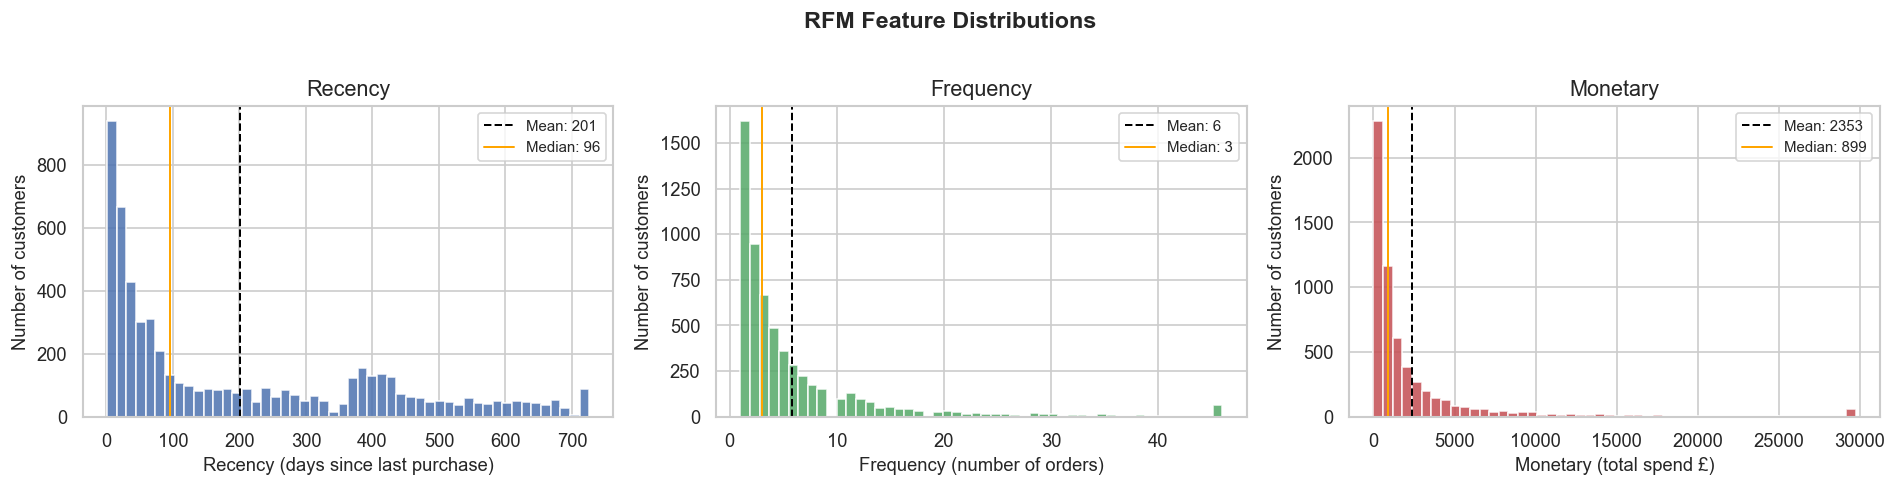

✅ Saved: rfm_distributions.png


In [3]:
# Univariate distributions for core RFM features
rfm_cols = ['Recency', 'Frequency', 'Monetary']
labels   = ['Recency (days since last purchase)',
            'Frequency (number of orders)',
            'Monetary (total spend £)']
colors   = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label, color in zip(axes, rfm_cols, labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.2, label=f'Median: {data.median():.0f}')
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel('Number of customers')
    ax.legend(fontsize=9)

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/cluster_plots/rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rfm_distributions.png")

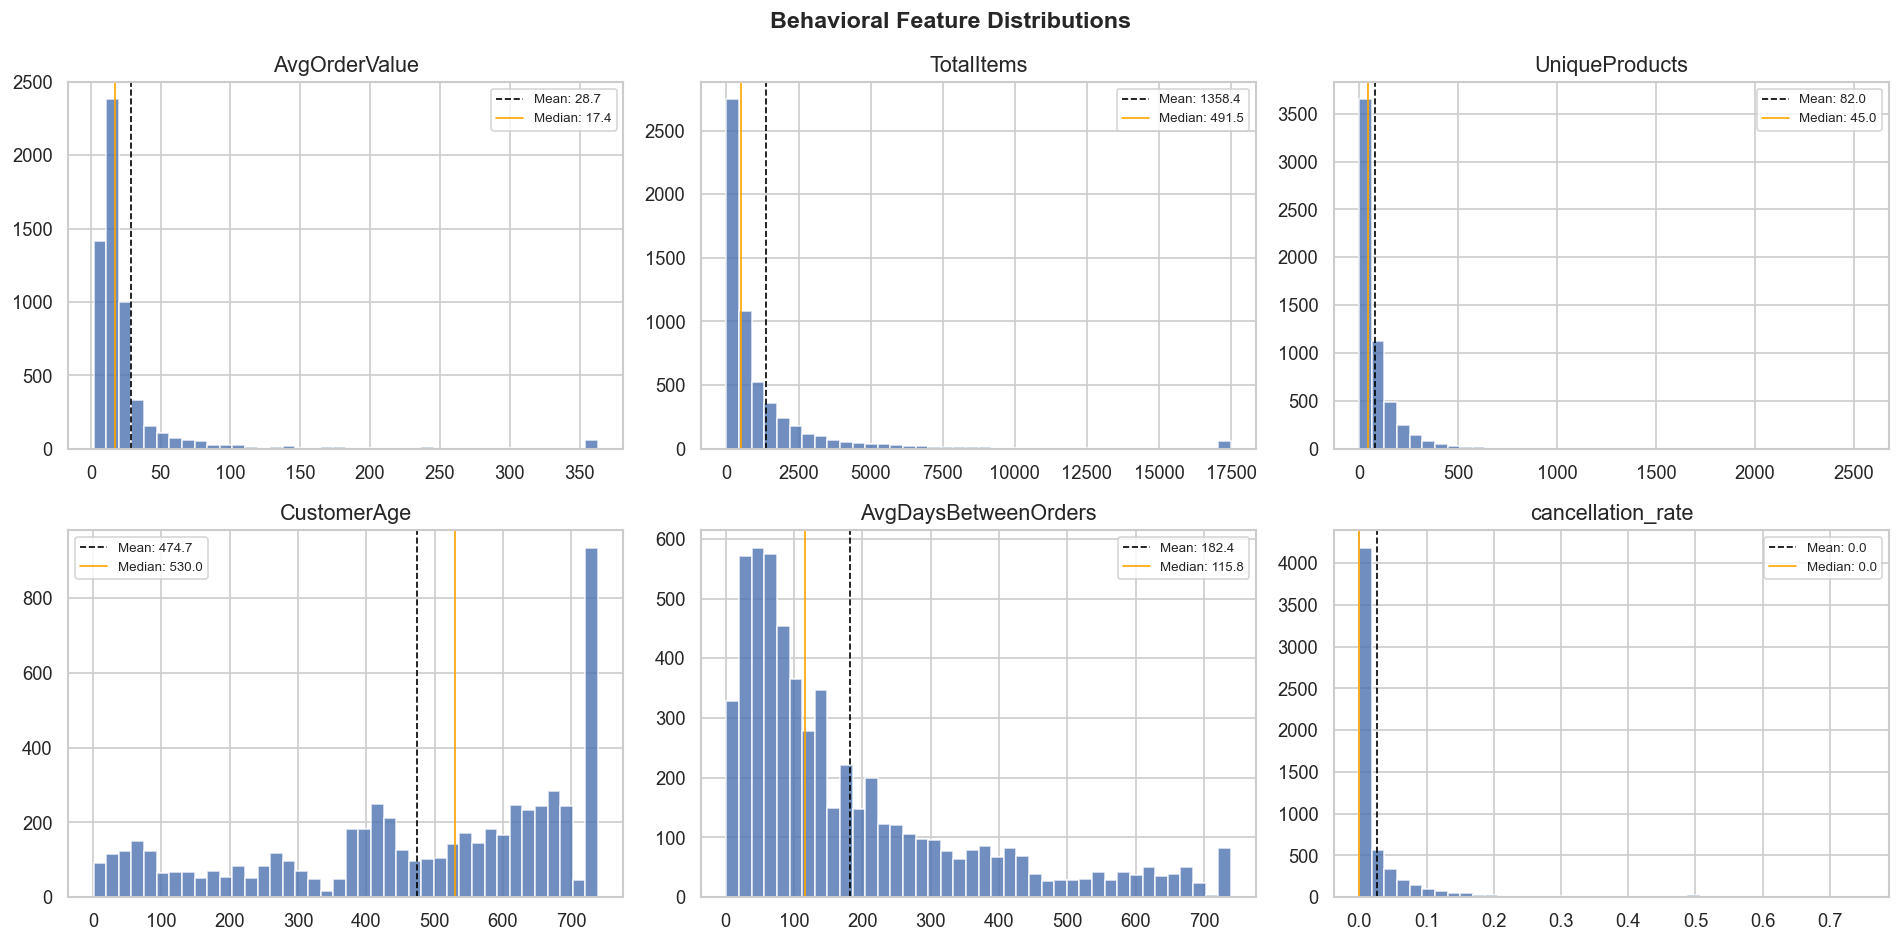

✅ Saved: behavioral_distributions.png


In [4]:
# Behavioral feature distributions
behav_cols = ['AvgOrderValue', 'TotalItems', 'UniqueProducts',
              'CustomerAge', 'AvgDaysBetweenOrders', 'cancellation_rate']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(behav_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(),   color='black',  linestyle='--', linewidth=1, label=f'Mean: {data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='-',  linewidth=1, label=f'Median: {data.median():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Behavioral Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/behavioral_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: behavioral_distributions.png")

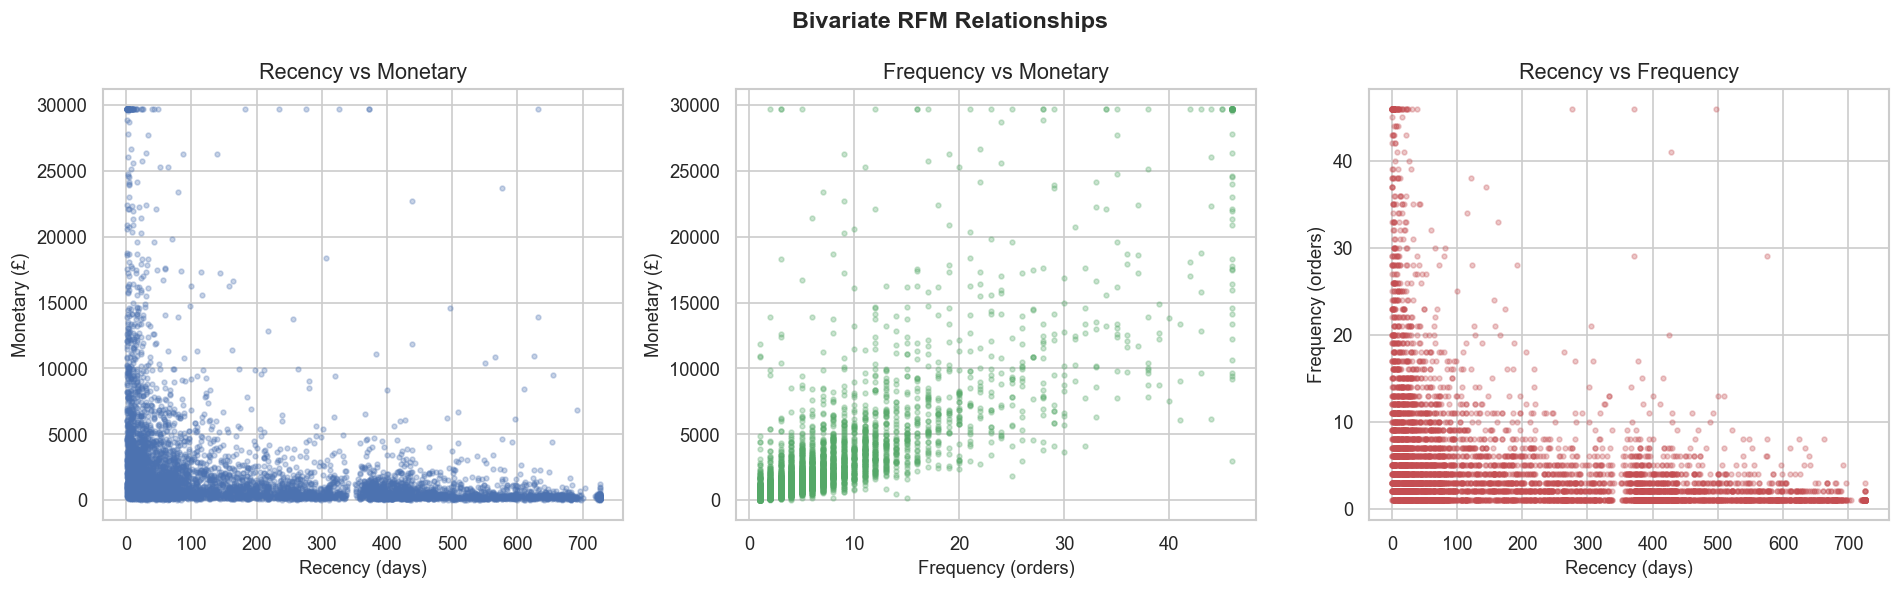

✅ Saved: rfm_bivariate.png


In [5]:
# Bivariate analysis — RFM relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Recency vs Monetary
axes[0].scatter(df['Recency'], df['Monetary'],
                alpha=0.3, s=8, color='#4C72B0')
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary')

# Frequency vs Monetary
axes[1].scatter(df['Frequency'], df['Monetary'],
                alpha=0.3, s=8, color='#55A868')
axes[1].set_xlabel('Frequency (orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary')

# Recency vs Frequency
axes[2].scatter(df['Recency'], df['Frequency'],
                alpha=0.3, s=8, color='#C44E52')
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Frequency (orders)')
axes[2].set_title('Recency vs Frequency')

plt.suptitle('Bivariate RFM Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/cluster_plots/rfm_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rfm_bivariate.png")

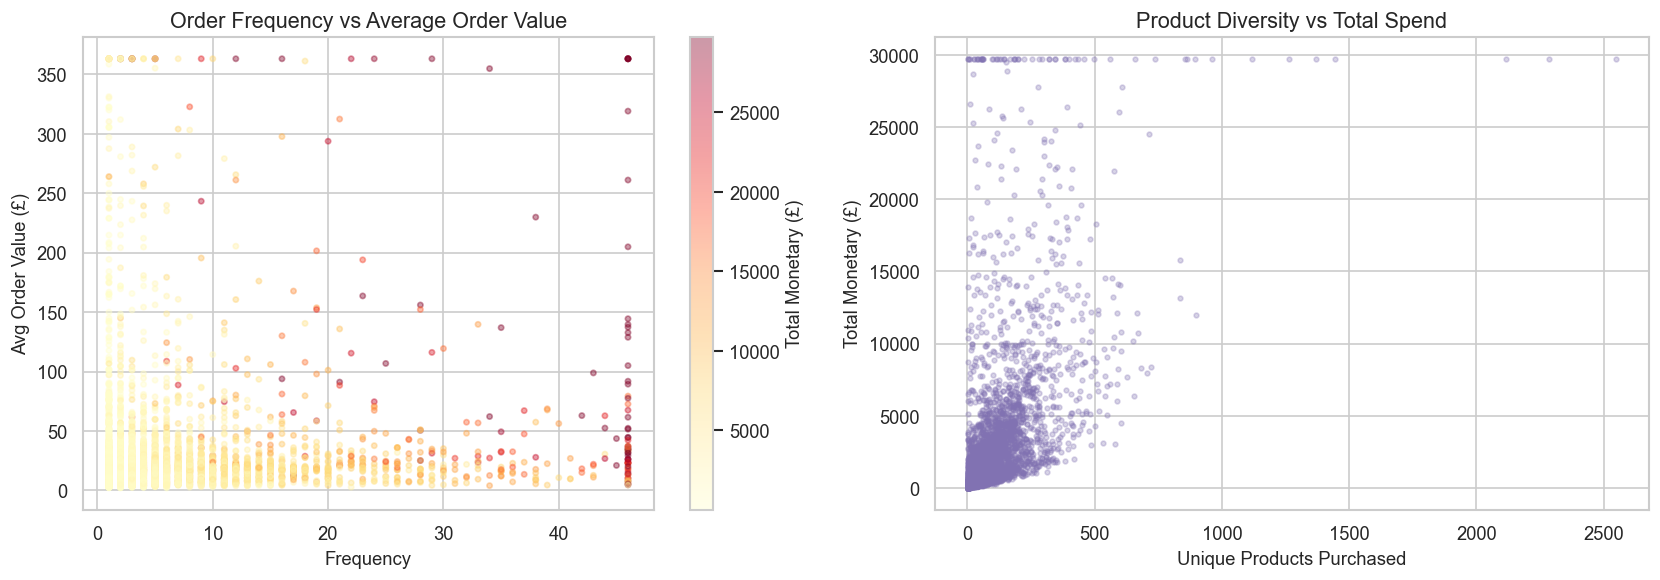

✅ Saved: spend_patterns.png


In [6]:
# Spend pattern analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AvgOrderValue vs Frequency
sc = axes[0].scatter(df['Frequency'], df['AvgOrderValue'],
                     c=df['Monetary'], cmap='YlOrRd',
                     alpha=0.4, s=10)
plt.colorbar(sc, ax=axes[0], label='Total Monetary (£)')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Avg Order Value (£)')
axes[0].set_title('Order Frequency vs Average Order Value')

# UniqueProducts vs Monetary
axes[1].scatter(df['UniqueProducts'], df['Monetary'],
                alpha=0.3, s=8, color='#8172B2')
axes[1].set_xlabel('Unique Products Purchased')
axes[1].set_ylabel('Total Monetary (£)')
axes[1].set_title('Product Diversity vs Total Spend')

plt.tight_layout()
plt.savefig('../results/cluster_plots/spend_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: spend_patterns.png")

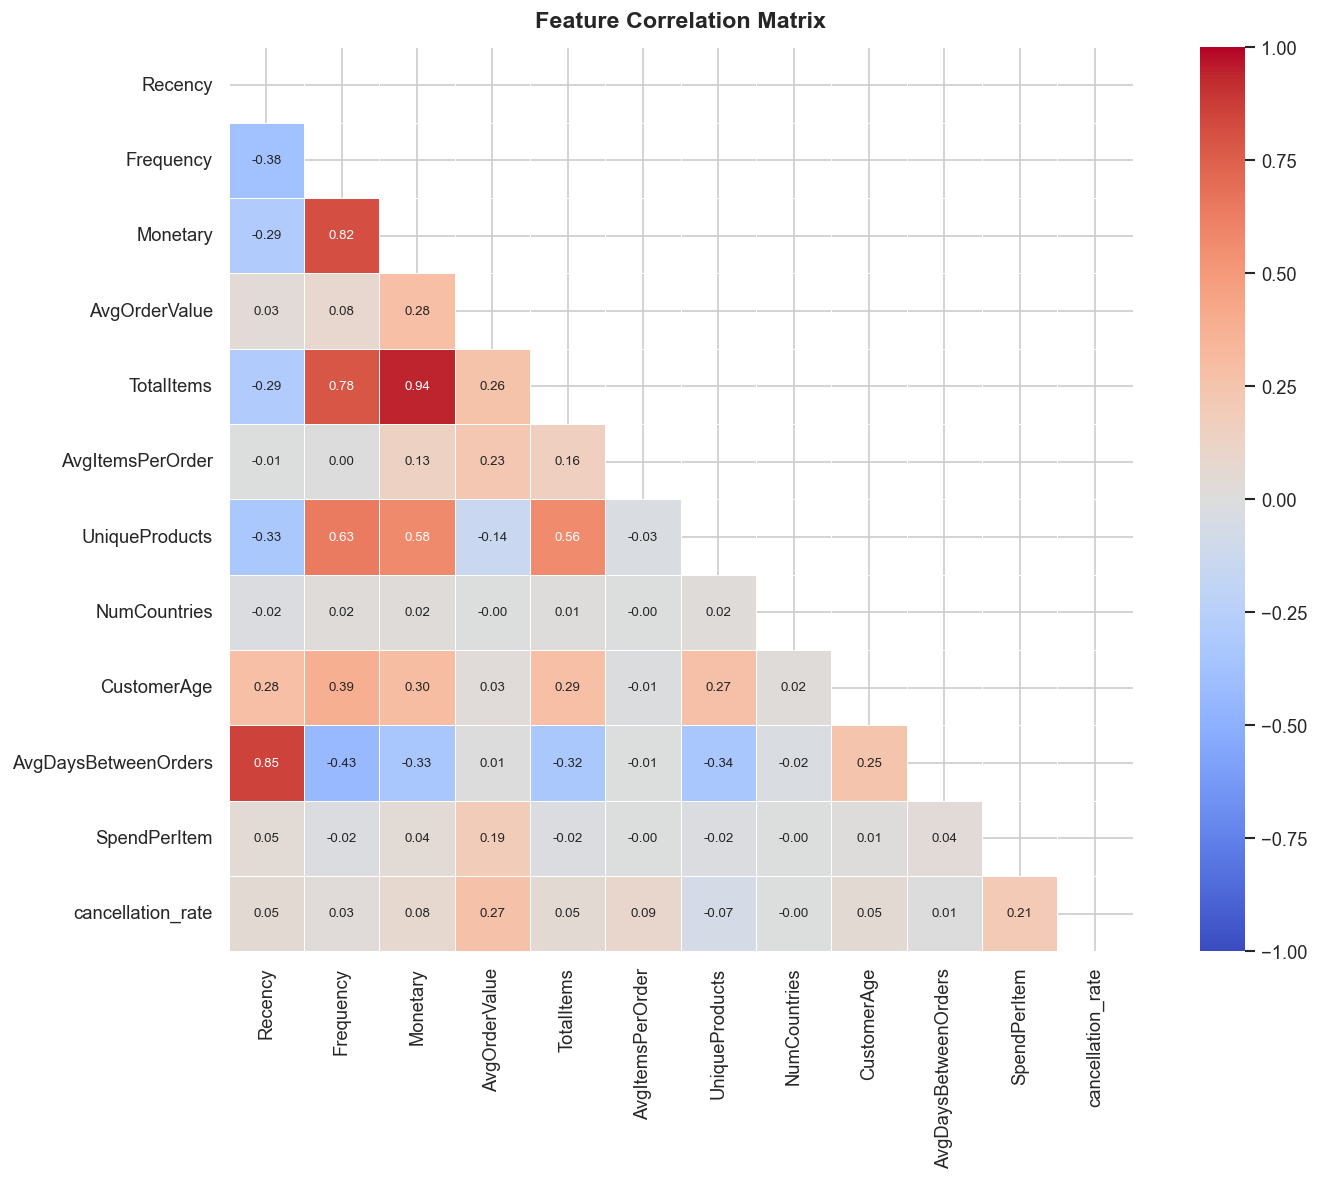

✅ Saved: correlation_heatmap.png


In [7]:
# Full correlation heatmap
feature_cols = [c for c in df.columns if c != 'Customer ID']
corr = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../results/cluster_plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

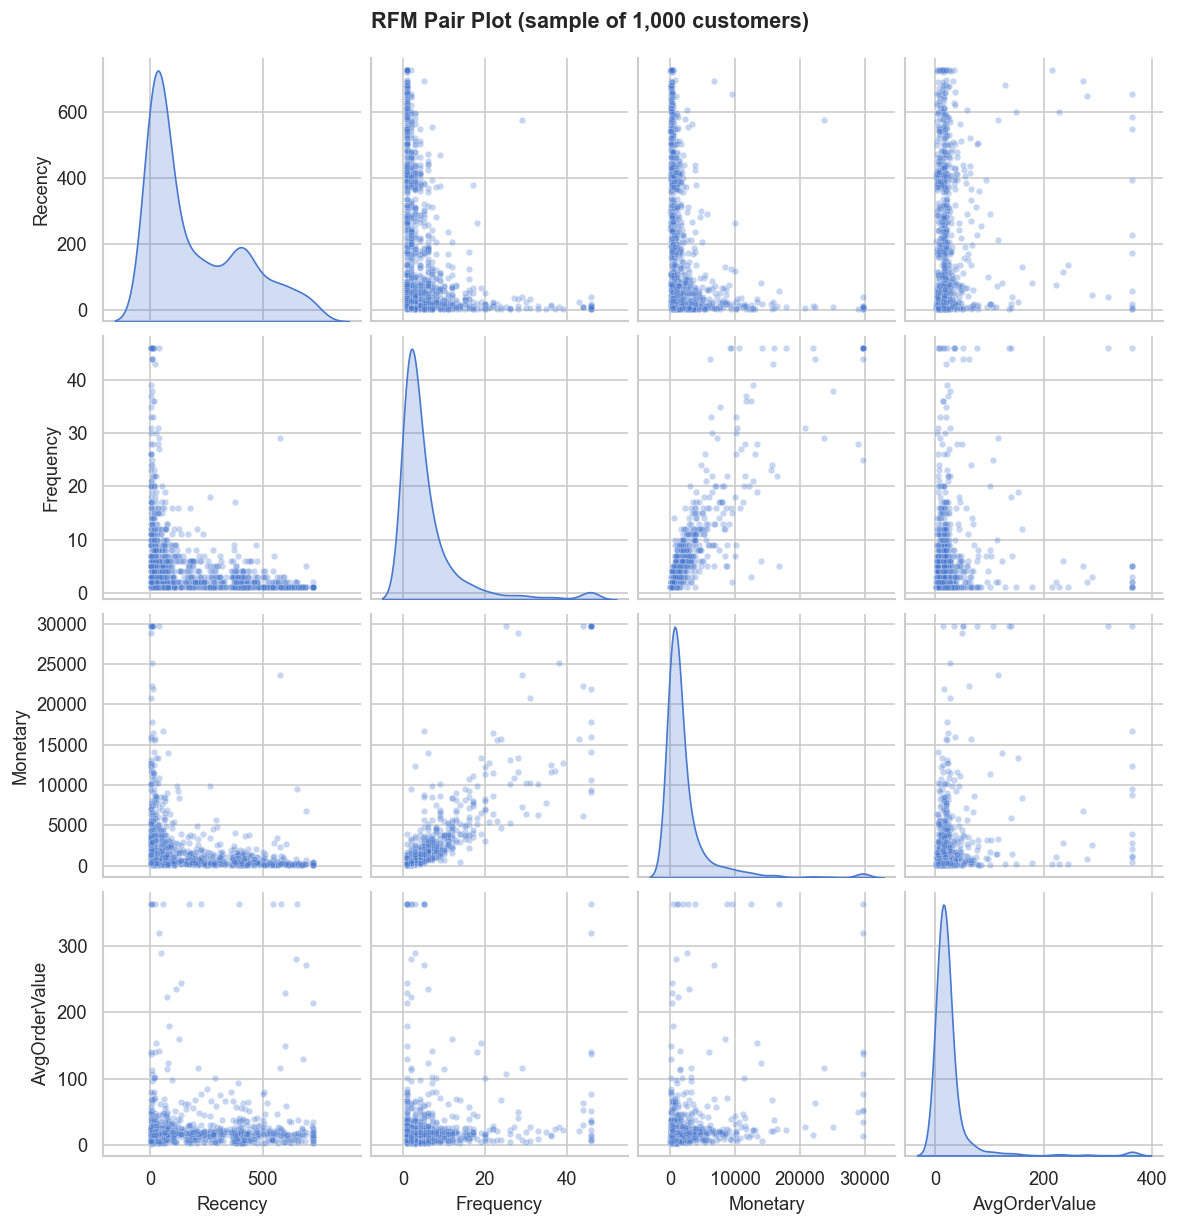

✅ Saved: rfm_pairplot.png


In [8]:
# Pair plot of RFM features
rfm_only = df[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue']].copy()

pair_plot = sns.pairplot(
    rfm_only.sample(min(1000, len(rfm_only)), random_state=42),
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kws={'fill': True}
)
pair_plot.figure.suptitle('RFM Pair Plot (sample of 1,000 customers)',
                           y=1.02, fontsize=13, fontweight='bold')
pair_plot.savefig('../results/cluster_plots/rfm_pairplot.png',
                  dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rfm_pairplot.png")

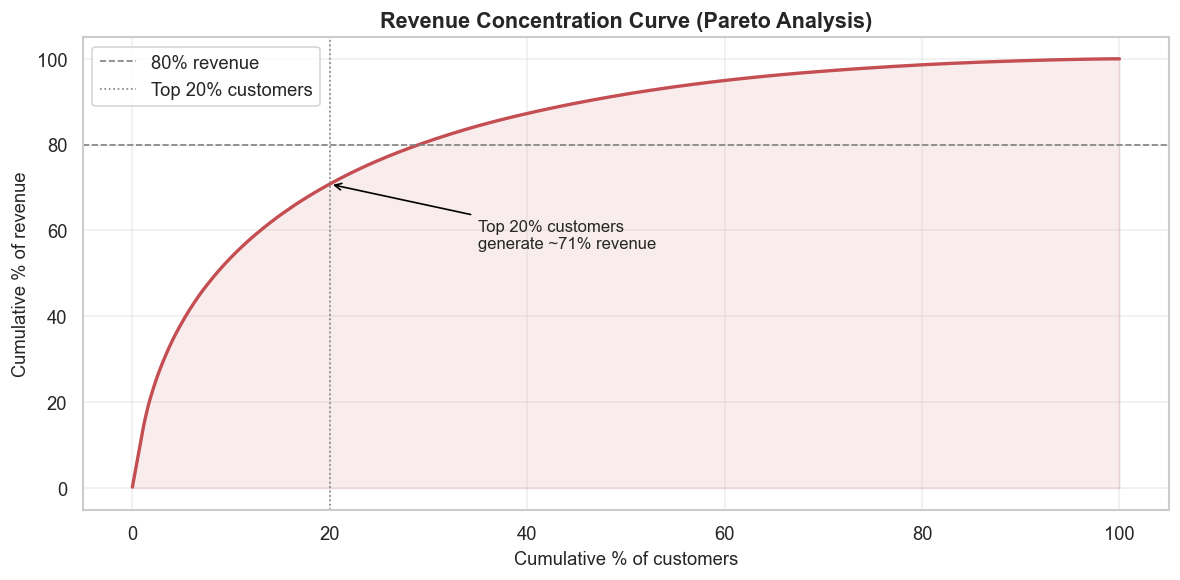

✅ Saved: pareto_analysis.png

💡 Key insight: Top 20% of customers generate ~71% of revenue


In [9]:
# Revenue concentration — top customers insight
df_sorted = df.sort_values('Monetary', ascending=False).reset_index(drop=True)
df_sorted['cumulative_revenue_pct'] = (
    df_sorted['Monetary'].cumsum() / df_sorted['Monetary'].sum() * 100
)
df_sorted['customer_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sorted['customer_pct'], df_sorted['cumulative_revenue_pct'],
        color='#C44E52', linewidth=2)
ax.axhline(80, color='gray', linestyle='--', linewidth=1, label='80% revenue')
ax.axvline(20, color='gray', linestyle=':',  linewidth=1, label='Top 20% customers')
ax.fill_between(df_sorted['customer_pct'],
                df_sorted['cumulative_revenue_pct'],
                alpha=0.1, color='#C44E52')
ax.set_xlabel('Cumulative % of customers')
ax.set_ylabel('Cumulative % of revenue')
ax.set_title('Revenue Concentration Curve (Pareto Analysis)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate the 80/20 point
top20_rev = df_sorted.loc[df_sorted['customer_pct'] <= 20, 'cumulative_revenue_pct'].max()
ax.annotate(f'Top 20% customers\ngenerate ~{top20_rev:.0f}% revenue',
            xy=(20, top20_rev),
            xytext=(35, top20_rev - 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

plt.tight_layout()
plt.savefig('../results/cluster_plots/pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: pareto_analysis.png")
print(f"\n💡 Key insight: Top 20% of customers generate ~{top20_rev:.0f}% of revenue")

Recency Buckets — Preview of Natural Segments
     RecencyBucket  Customers  AvgMonetary  AvgFrequency
    Active (0-30d)       1648  4601.365754     10.873180
   Recent (31-90d)       1241  2373.605847      5.701048
 Lapsing (91-180d)        589  1823.405643      4.964346
At-risk (181-365d)        791  1245.053744      3.345133
      Lost (365d+)       1609   772.466976      2.139838


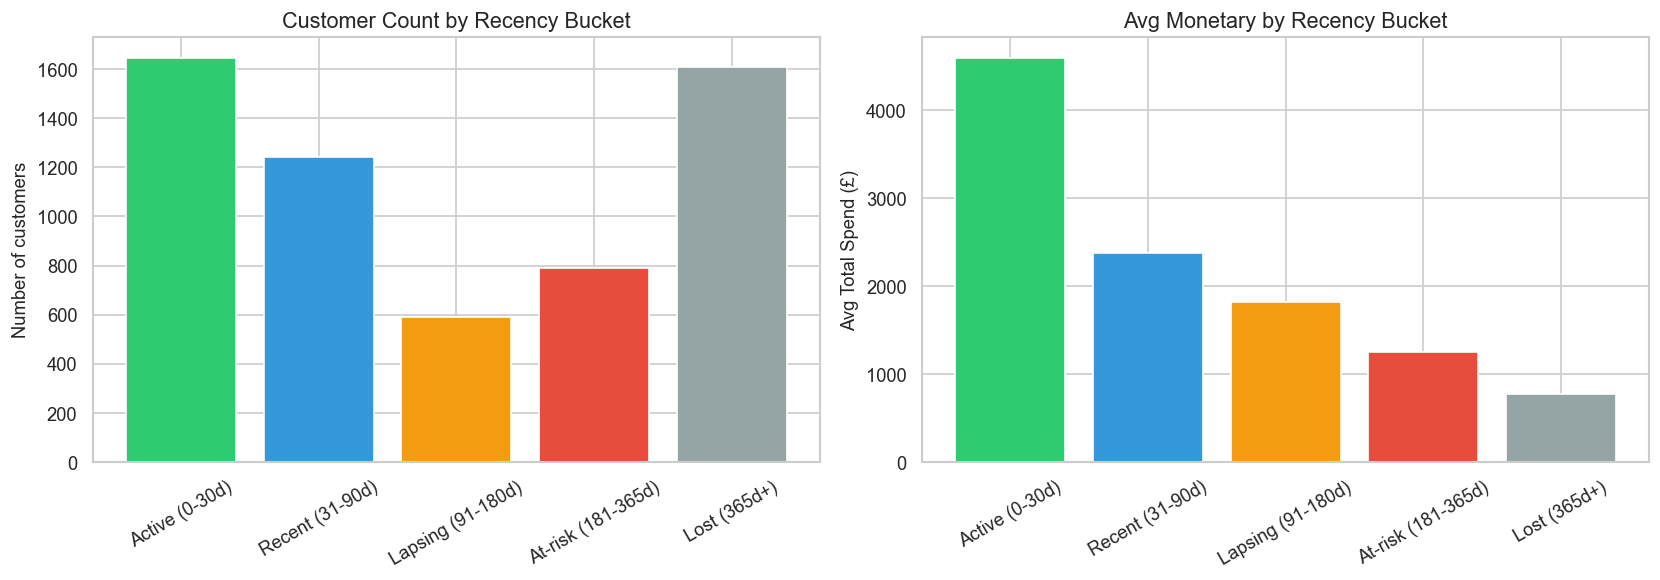

✅ Saved: recency_buckets.png


In [10]:
# Manual recency buckets to preview natural segments
df['RecencyBucket'] = pd.cut(
    df['Recency'],
    bins=[0, 30, 90, 180, 365, 9999],
    labels=['Active (0-30d)', 'Recent (31-90d)',
            'Lapsing (91-180d)', 'At-risk (181-365d)', 'Lost (365d+)']
)

bucket_stats = df.groupby('RecencyBucket', observed=True).agg(
    Customers  = ('Customer ID', 'count'),
    AvgMonetary = ('Monetary', 'mean'),
    AvgFrequency = ('Frequency', 'mean')
).reset_index()

print("Recency Buckets — Preview of Natural Segments")
print(bucket_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_b = ['#2ecc71','#3498db','#f39c12','#e74c3c','#95a5a6']

axes[0].bar(bucket_stats['RecencyBucket'], bucket_stats['Customers'],
            color=colors_b, edgecolor='white')
axes[0].set_title('Customer Count by Recency Bucket')
axes[0].set_ylabel('Number of customers')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(bucket_stats['RecencyBucket'], bucket_stats['AvgMonetary'],
            color=colors_b, edgecolor='white')
axes[1].set_title('Avg Monetary by Recency Bucket')
axes[1].set_ylabel('Avg Total Spend (£)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/cluster_plots/recency_buckets.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: recency_buckets.png")

# Drop temp column
df.drop(columns=['RecencyBucket'], inplace=True)

In [11]:
# EDA findings summary
print("=" * 55)
print("  EDA COMPLETE — KEY FINDINGS")
print("=" * 55)
print(f"  Total customers analysed   : {len(df):,}")
print(f"  Avg Recency                : {df['Recency'].mean():.0f} days")
print(f"  Avg Frequency              : {df['Frequency'].mean():.1f} orders")
print(f"  Avg Monetary               : £{df['Monetary'].mean():.2f}")
print(f"  Top 20% revenue share      : ~{top20_rev:.0f}%")
print()
print("  Plots saved to results/cluster_plots/:")
plots = [
    'rfm_distributions.png',
    'behavioral_distributions.png',
    'rfm_bivariate.png',
    'spend_patterns.png',
    'correlation_heatmap.png',
    'rfm_pairplot.png',
    'pareto_analysis.png',
    'recency_buckets.png',
]
for p in plots:
    print(f"    ✅ {p}")
print("=" * 55)
print("\n✅ Ready for Notebook 03 — Feature Engineering")

  EDA COMPLETE — KEY FINDINGS
  Total customers analysed   : 5,878
  Avg Recency                : 201 days
  Avg Frequency              : 5.8 orders
  Avg Monetary               : £2352.91
  Top 20% revenue share      : ~71%

  Plots saved to results/cluster_plots/:
    ✅ rfm_distributions.png
    ✅ behavioral_distributions.png
    ✅ rfm_bivariate.png
    ✅ spend_patterns.png
    ✅ correlation_heatmap.png
    ✅ rfm_pairplot.png
    ✅ pareto_analysis.png
    ✅ recency_buckets.png

✅ Ready for Notebook 03 — Feature Engineering
